In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from nn_tools import Qfirst, Qfollowing, optimiers_list, one_batch_layers, EarlyStoppingList
import torch.nn as nn
from learning_tools import peak_one, algo_p, algo_e, update, perform_bids, assess_models, legal_bid
import seaborn as sns
import matplotlib.pyplot as plt
from torch import save
import tools

In [4]:
def init_variables(nb_layers, include_early_stopping, min_es_list, patience_es_list, init_models, Q_models = None, init_D = True, D = None):
    if init_D:
        D = [[torch.empty(0), torch.empty(0)] for _ in range(nb_layers)]  # Un dataset D par couche
    all_actions = list(range(36))  # 36 actions possibles
    if init_models:
        Q_models = [Qfirst() if i == 0 else Qfollowing() for i in range(nb_layers)]
    losses=[]
    val_losses = []
    if include_early_stopping:
        early_stop_list = EarlyStoppingList(min_es_list, patience_es_list)
    else:
        early_stop_list = None
    return D, all_actions, Q_models, losses, val_losses, early_stop_list


def augment_dataset(data, Q_models, nb_layers, D, epsilon, all_actions):
    bidding_history = np.zeros(36) # array de 5x36 pour enregistrer l'historique des enchères
    x1, x2, scores = peak_one(data)

    for j in range(nb_layers):
        C = np.zeros(36)  
        hand = x1 if (j+1) % 2 == 1 else x2  # main du joueur actuel

        #### Calcul des coûts des actions: policy evaluation ####
        for i, action in enumerate(all_actions):
            C[i] = algo_p(action,x1,x2,scores,bidding_history,Q_models,nb_layers)
        
        # state = main si première couche sinon state = main + enchère_précédente
        state = torch.tensor(hand, dtype=torch.float32) if j == 0 else torch.tensor(np.concatenate([hand, bidding_history]), dtype=torch.float32)
        D=update(D,state,C,j) #ajout de l'expérience dans le dataset D_j
        
        #### Exploration ####
        next_a = algo_e(Q_models[j], state, epsilon, all_actions)  # Sélection avec Q_j
        if next_a == 0 or not legal_bid(next_a, bidding_history):  # si l'action est PASS ou n'est pas légale
            break  
        bidding_history[next_a] = 1  # enregistrement de l'action choisie dans l'historique des enchères
    return D


def remove_lines(D, max_length, offset):
    for k in range(len(D)):
        if D[k][0].shape[0]>max_length:
            D[k][0]=D[k][0][offset:]
            D[k][1]=D[k][1][offset:]
    return D


def train_models(Q_models, D, optimisers, loss, losses, batch_size, device):
    opti_list = optimisers if optimisers is not None else optimiers_list(Q_models)
    losses.append(one_batch_layers(Q_models, D, opti_list,loss, batch_size, device))
    return losses

def update_validation_loss(Q_models, val_dataset, val_losses, nb_iteration, include_early_stopping, early_stop_list = None):
    if nb_iteration%50000 == 0 and nb_iteration > 0:
        val_losses.append(assess_models(Q_models, val_dataset))
        if include_early_stopping and nb_iteration > 100000 \
            and early_stop_list.test_stop(val_losses[-1], [Q.state_dict() for Q in Q_models]):
            early_stop_list.set_best_weights(Q_models)
            return val_losses, True
    return val_losses, False


def plot_losses(losses, offset = 0, window = 100):
    _, axs = plt.subplots(1,losses.shape[1], figsize = (4*losses.shape[1], 4))
    if losses.shape[1] == 1:
        axs = [axs]

    for k in range(losses.shape[1]):
        if not np.all(np.isnan(losses[offset:,k])):
            axs[k].plot(np.convolve(losses[:,k], np.ones(window) / window, mode='valid')[offset:])
            axs[k].set_title(f"Loss {k}th layer")
            axs[k].set_yscale('log')
    plt.tight_layout()
    plt.show()

In [5]:
def learning_algo(data, val_dataset, max_iter=100, nb_layers=5, epsilon=0.1,
                  init_models = True, Q_models = None,
                  init_D = True, D = None,
                  validation = True, 
                  include_early_stopping = True, min_es_list = [1e-2]*5, patience_es_list = [100]*5,
                  loss= nn.MSELoss(),
                  optimisers = None,
                  batch_size=50, device='cpu'):
    
    D, all_actions, Q_models, losses, val_losses, early_stop_list \
        = init_variables(nb_layers, include_early_stopping, min_es_list, patience_es_list, init_models, Q_models, init_D, D)
    
    for number_iteration in tqdm(range(max_iter)):
        D = augment_dataset(data, Q_models, nb_layers, D, epsilon, all_actions)
        if number_iteration > 1000000:
            D = remove_lines(D, 1000000, 100000)
        losses = train_models(Q_models, D, optimisers, loss, losses, batch_size, device)
        if validation:
            val_losses, stop = update_validation_loss(Q_models, val_dataset, val_losses, number_iteration, include_early_stopping, early_stop_list)
            if stop:
                break
    return Q_models, np.array([np.array(l) for l in losses]), np.array([np.array(l) for l in val_losses]), D

In [11]:
data = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range(10)])
val_dataset = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range (10, 12)])

# Training

In [7]:
Q_models, losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=3, max_iter=1,
                                                epsilon = 0.1, 
                                                validation = False, include_early_stopping = False, 
                                                init_models=True, init_D=True)

100%|██████████| 1/1 [00:02<00:00,  2.16s/it]


In [ ]:
Q_models[0] = torch.load("models/two_layers/l0.pth")
Q_models[1] = torch.load("models/two_layers/l1.pth")
Q_models[2] = torch.load("models/two_layers/l1.pth")

C:\Users\Chardin Pierre\AppData\Local\Temp\ipykernel_11580\1777283471.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Q_models[0] = torch.load("models/two_layers/l0.pth"

In [57]:
opti_list = [torch.optim.AdamW(model.parameters(), 
                                 lr = 0.001,
                                 betas = (0.9, 0.999),
                                 weight_decay=0.01) for model in Q_models]
for k in range(1000):
    Q_models, new_losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=3, max_iter=2000,
                                                    epsilon = 0, 
                                                    validation = False, include_early_stopping = False, 
                                                    optimisers=opti_list,
                                                    init_models=False, Q_models=Q_models,
                                                    init_D=False, D=D)
    losses = np.concatenate([losses, new_losses], axis = 0)

  6%|▋         | 125/2000 [00:56<14:08,  2.21it/s]


KeyboardInterrupt: 

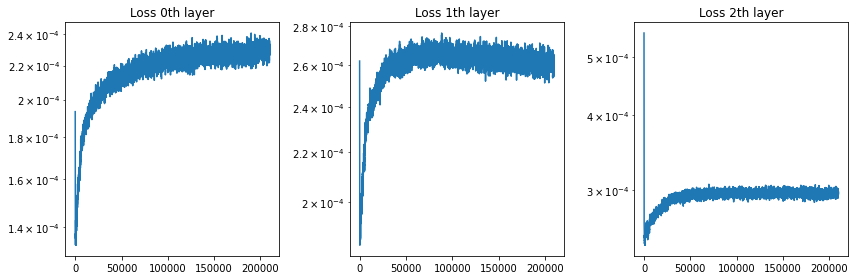

In [58]:
plot_losses(losses, offset=40)

In [18]:
x1, x2, r = peak_one(val_dataset)
tools.ohe_to_hand(x1).pprint()
print()
tools.ohe_to_hand(x2).pprint()
print(r)
perform_bids(x1, x2, np.zeros(36), Q_models, 3)

♠ 765432
♥ QT
♦ J
♣ K643

♠ AKQT8
♥ 96
♦ A762
♣ J9
[0.8  0.68 0.6  0.6  1.   0.72 0.64 0.6  0.56 1.   0.68 0.6  0.56 0.52
 1.   0.64 0.56 0.52 0.52 0.84 0.6  0.52 0.52 0.48 0.72 0.56 0.52 0.48
 0.48 0.68 0.56 0.48 0.48 0.48 0.64 0.52]


array([1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

In [19]:
bid0 = torch.argmax(Q_models[0](torch.tensor(x1, dtype = torch.float32))).detach()
Q_models[0](torch.tensor(x1, dtype = torch.float32)), bid0

(tensor([0.8710, 0.8754, 0.8150, 0.7470, 0.8638, 0.7409, 0.7592, 0.7202, 0.6982,
         0.7443, 0.7121, 0.7240, 0.6830, 0.6946, 0.7040, 0.6546, 0.6681, 0.6609,
         0.6323, 0.7105, 0.6173, 0.6024, 0.5805, 0.5901, 0.6529, 0.5678, 0.5933,
         0.5702, 0.5689, 0.6008, 0.5467, 0.5680, 0.5344, 0.5401, 0.5667, 0.5350],
        grad_fn=<SigmoidBackward0>),
 tensor(1))

In [20]:
bids = np.zeros(36)
bids[bid0] = 1
bid2 = torch.argmax(Q_models[1](torch.tensor(np.concatenate([x1,bids]), dtype = torch.float32))).detach()
Q_models[1](torch.tensor(np.concatenate([x1,bids]), dtype = torch.float32))

tensor([9.0057e-01, 1.4567e-08, 7.2595e-01, 7.1941e-01, 9.0781e-01, 7.3326e-01,
        7.9314e-01, 6.5662e-01, 6.3177e-01, 7.4226e-01, 6.8868e-01, 7.4350e-01,
        6.3561e-01, 6.5868e-01, 6.6419e-01, 6.6001e-01, 7.3363e-01, 7.1361e-01,
        6.1536e-01, 7.3566e-01, 6.1763e-01, 6.4704e-01, 5.6352e-01, 5.8409e-01,
        5.6122e-01, 5.9013e-01, 6.4517e-01, 5.5486e-01, 5.7699e-01, 6.0960e-01,
        5.5229e-01, 5.4249e-01, 5.2407e-01, 5.3173e-01, 5.6318e-01, 5.2886e-01],
       grad_fn=<SigmoidBackward0>)

In [21]:
bids[bid2] = 1
Q_models[2](torch.tensor(np.concatenate([x1,bids]), dtype = torch.float32))

tensor([9.2046e-01, 3.3329e-09, 3.9843e-09, 1.5678e-11, 5.9270e-06, 7.2410e-01,
        7.2576e-01, 6.1547e-01, 6.3791e-01, 8.9760e-01, 6.7342e-01, 6.7469e-01,
        5.8277e-01, 6.0040e-01, 8.3349e-01, 6.4346e-01, 6.3495e-01, 5.5565e-01,
        5.6357e-01, 8.4690e-01, 6.0532e-01, 5.9917e-01, 5.3219e-01, 5.4308e-01,
        7.1489e-01, 5.6449e-01, 5.6745e-01, 5.1719e-01, 5.2499e-01, 6.5585e-01,
        5.3510e-01, 5.3924e-01, 4.9546e-01, 5.0965e-01, 6.0929e-01, 5.1857e-01],
       grad_fn=<SigmoidBackward0>)

In [59]:
assess_models(Q_models, val_dataset)*25

array([22.41620179, 22.10009064, 21.17010056])

In [83]:
save(Q_models[0], "models/three_layers/l0.pth")
save(Q_models[1], "models/three_layers/l1.pth")
save(Q_models[2], "models/three_layers/l2.pth")

# Test

In [2]:
Q_models = []
Q_models.append(torch.load("models/three_layers/l0.pth"))
Q_models.append(torch.load("models/three_layers/l1.pth"))
Q_models.append(torch.load("models/three_layers/l2.pth"))

C:\Users\Chardin Pierre\AppData\Local\Temp\ipykernel_21184\461798272.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Q_models.append(torch.load("models/three_layers/l0.p

In [4]:
test_dataset = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range (12, 14)])
results, counts = assess_models(Q_models, test_dataset, return_counts=True)
results*25

c:\Users\Chardin Pierre\OneDrive - CentraleSupelec\Bureau\CS\3a\DL\brige\RL-for-bridge-bidding\learning_tools.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  state = torch.tensor(hand, dtype=torch.float32) if i == 0 else torch.tensor(
c:\Users\Chardin Pierre\OneDrive - CentraleSupelec\Bureau\CS\3a\DL\brige\RL-for-bridge-bidding\learning_tools.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return scores[last_contract], last_layer


array([22.50153846, 22.10227122, 21.15571186])

In [8]:
25*(1-results)

array([2.49846154, 2.89772878, 3.84428814])

In [9]:
np.sum(counts*(1-results))/np.sum(counts)*25

3.2036499999988512